# 03 — Calibration + Conformal + Policy Layer

Improved path (contrast with notebook 02):
1. 1D-CNN with **value + mask + dt** channels (honors missing data)
2. Temperature scaling on a held-out calibration set
3. Split conformal prediction → prediction sets
4. **PolicyLayer**: expected cost + dwell + hysteresis + abstain

In [ ]:
import numpy as np

from sentinelai.baseline.weak_controls import forward_fill_only, summarize_weak, weak_decide
from sentinelai.data.skab import load_all_scenarios
from sentinelai.data.windows import inject_gaps, make_windows, temporal_split
from sentinelai.models.cnn_detector import predict_logits, predict_proba, train_detector
from sentinelai.policy.decision import PolicyLayer
from sentinelai.uncertainty.calibration import (
    calibrate_probs,
    expected_calibration_error,
    fit_temperature,
    reliability_curve
)
from sentinelai.uncertainty.conformal import ConformalPredictor

# TO DO: better handling of gaps - transformer model?

In [28]:
df = load_all_scenarios(("valve1", "valve2"))

# gapped = inject_gaps(df)
# batch = make_windows(gapped)

filled = forward_fill_only(df)
batch = make_windows(filled)
train, cal, test = temporal_split(batch)


print(len(train.labels), len(cal.labels), len(test.labels))

2689 897 897


In [29]:
df = load_all_scenarios(("valve1", "valve2"))

filled = forward_fill_only(df)
batch = make_windows(filled)
train, cal, test = temporal_split(batch)
print(len(train.labels), len(cal.labels), len(test.labels))



2689 897 897


In [30]:
result = train_detector(train, val=cal, epochs=100, values_only=True)
model = result.model
print(f"Final train loss: {result.train_losses[-1]:.4f}")
print(f"Final val loss: {result.val_losses[-1]:.4f}")


Final train loss: 0.4254
Final val loss: 0.3540


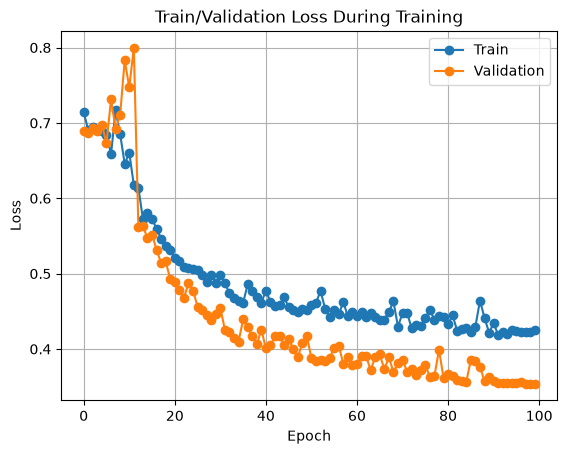

In [31]:
import matplotlib.pyplot as plt

plt.plot(result.train_losses, marker='o', label='Train')
plt.plot(result.val_losses, marker='o', label='Validation')
plt.title("Train/Validation Loss During Training")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [32]:
logits_cal = predict_logits(model, cal, values_only=True)
print(f"logits_cal.shape: {logits_cal.shape}")
print(f"cal.labels.shape: {cal.labels.shape}")

T = fit_temperature(logits_cal, cal.labels)
print(f"Temperature T = {T:.3f}")

p_raw = predict_proba(model, test, values_only=True)
p_cal = calibrate_probs(predict_logits(model, test, values_only=True), T)
print(f"ECE raw: {expected_calibration_error(p_raw, test.labels):.3f}")
print(f"ECE calibrated: {expected_calibration_error(p_cal, test.labels):.3f}")

logits_cal.shape: (897, 2)
cal.labels.shape: (897,)
Temperature T = 0.583
ECE raw: 0.084
ECE calibrated: 0.039


In [37]:

centers, confs_raw, accs_raw = reliability_curve(p_raw, test.labels)
centers, confs_cal, accs_cal = reliability_curve(p_cal, test.labels)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot([0, 1], [0, 1], 'k--', label='perfect calibration')
ax.plot(confs_raw, accs_raw, 'o-', label='Raw (uncalibrated)')
ax.plot(confs_cal, accs_cal, 'o-', label='Calibrated')
ax.set_xlabel('Mean confidence ')
ax.set_ylabel('Accuracy')
ax.set_title('Reliability diagram — uncalibrated CNN scores')
ax.legend()
plt.show()

NameError: name 'reliability_curve' is not defined

In [33]:
p_cal_full = np.stack([1 - p_cal, p_cal], axis=1)
p_cal_calib = calibrate_probs(logits_cal, T)
p_cal_calib_full = np.stack([1 - p_cal_calib, p_cal_calib], axis=1)

conf = ConformalPredictor(alpha=0.10, mondrian=True)
conf.fit(p_cal_calib_full, cal.labels)
sets = conf.predict_set(p_cal_full)
print("Example sets:", sets[:5])

Example sets: [['nominal', 'hazard'], ['nominal', 'hazard'], ['nominal'], ['nominal'], ['nominal']]


In [34]:
policy = PolicyLayer()
policy.reset()
records = []
for i in range(len(test.labels)):
    rec = policy.decide(
        p_hazard_raw=float(p_raw[i]),
        p_hazard_calibrated=float(p_cal[i]),
        conformal_set=sets[i],
        coverage=float(test.coverage[i]),
    )
    records.append(rec)

actions = [r.action for r in records]
print({a: actions.count(a) for a in set(actions)})
print("Sample audit:", records[0].to_dict())

{'nominal': 1, 'abstain': 301, 'advisory': 2, 'alarm': 593}
Sample audit: {'timestamp': '2026-06-28T19:58:31.194787+00:00', 'action': 'abstain', 'p_hazard': 0.26649776101112366, 'p_hazard_calibrated': 0.1497779939989679, 'conformal_set': ['nominal', 'hazard'], 'coverage': 1.0, 'dwell_votes': 0, 'reason': 'ambiguous conformal set {nominal, hazard}', 'model_version': 'cnn_v1', 'extras': {}}


In [35]:
# Weak baseline from notebook 02: values-only CNN, no calibration, auto-trip
filled = forward_fill_only(df)
batch_weak = make_windows(filled)
train_w, cal_w, test_w = temporal_split(batch_weak)
weak_result = train_detector(train_w, val=cal_w, epochs=10, values_only=True)
p_weak = predict_proba(weak_result.model, test_w, values_only=True)
weak_decisions = [weak_decide(float(p), 0.5) for p in p_weak]
weak = summarize_weak(weak_decisions)

improved = {
    "alarm": actions.count("alarm"),
    "advisory": actions.count("advisory"),
    "abstain": actions.count("abstain"),
    "auto_trip": actions.count("alarm"),  # policy uses dwell; not single-frame
}
print("Weak (1D-CNN, values only):", weak)
print("Improved:", improved)

Weak (1D-CNN, values only): {'n_alarm': 897, 'n_advisory': 0, 'n_nominal': 0, 'n_auto_trip': 897, 'alarm_rate': 1.0}
Improved: {'alarm': 593, 'advisory': 2, 'abstain': 301, 'auto_trip': 593}


## Stale input → abstain

Windows with low `coverage` should route to **abstain** instead of forcing a classification.

In [36]:
low_cov = test.coverage < 0.75
abstain_rate = sum(r.action == 'abstain' for i, r in enumerate(records) if low_cov[i]) / max(low_cov.sum(), 1)
print(f"Abstain rate on low-coverage windows: {abstain_rate:.2%}")

Abstain rate on low-coverage windows: 0.00%
